# **Gradient-Based Feature Importance (Saliency Maps)**

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input
from tensorflow.keras.preprocessing import image

In [ ]:
# Download a different chest X-ray image from the COVID Chest X-ray dataset
img_url = 'https://github.com/ieee8023/covid-chestxray-dataset/raw/master/images/000003-2.jpg'

##for uploading file from computer
#img_path = "/content/cddaf02f39a1c4a1f3975d16091e59ba.jpg"

img_path = tf.keras.utils.get_file('demo_cxr_new.jpg', img_path)
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
x_input = np.expand_dims(img_array, axis=0)
x_input = preprocess_input(x_input.copy())

In [ ]:
# Load pretrained DenseNet121 (placeholder for CheXNet)
model = DenseNet121(weights='imagenet')
preds = model.predict(x_input)
class_idx = np.argmax(preds[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [ ]:
# Compute gradients for saliency map
with tf.GradientTape() as tape:
    x_tensor = tf.convert_to_tensor(x_input)
    tape.watch(x_tensor)
    output_tensor = model(x_tensor)
    pred_score = output_tensor[0][class_idx]
grads = tape.gradient(pred_score, x_tensor)[0].numpy()

# Normalize saliency map
saliency = np.max(np.abs(grads), axis=-1)
saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min())

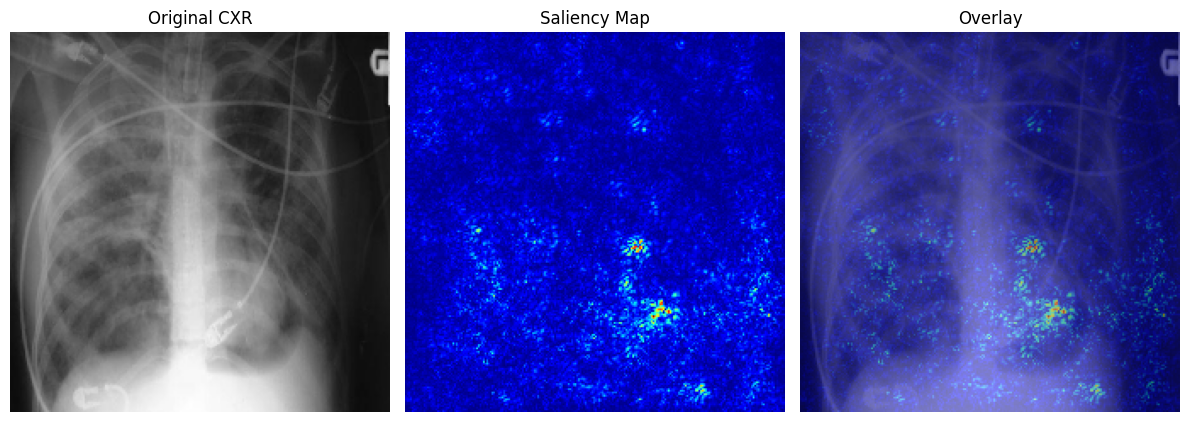

Predicted class index: 111
Prediction confidence: 0.76160294


In [ ]:
# Plot original image, saliency map, and overlay using jet colormap
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original CXR")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(saliency, cmap='jet')
plt.title("Saliency Map")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img, cmap='gray')
plt.imshow(saliency, cmap='jet', alpha=0.5)
plt.title("Overlay")
plt.axis('off')

plt.tight_layout()
plt.show()

print("Predicted class index:", class_idx)
print("Prediction confidence:", preds[0][class_idx])

# **Neural Network Decision Boundary Visualizer**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

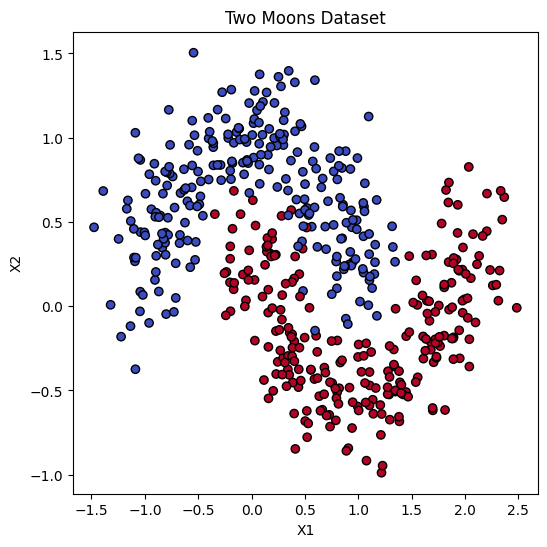

In [ ]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# Generate a nonlinear 2D dataset
X, y = make_moons(
    n_samples=500,
    noise=0.20,
    random_state=42
)

# Combine into the same format used later in the notebook
data = np.column_stack((X, y))

# Visualize
plt.figure(figsize=(6,6))
plt.scatter(
    data[:,0],
    data[:,1],
    c=data[:,2],
    cmap='coolwarm',
    edgecolors='k'
)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Two Moons Dataset")
plt.show()

In [ ]:
X = data[:, :-1]
y = data[:, -1]

In [ ]:
##defining the graph
def loss_acc_graph(train_hist):
    """
    Generates a visualization of the training and validation loss and accuracy over epochs.

    Parameters:
    - train_hist (dict): A dictionary containing the training history. This dictionary should have the keys
                         'train loss' and 'train accuracy'. If validation data is present, it should also
                         contain 'validation loss' and 'validation accuracy'.

    The function checks if validation data is available by looking at the length of the `train_hist` dictionary;
    if it contains four keys, it assumes validation data is available and plots it alongside the training data.
    """
    plt.figure(figsize=(12, 7))

    plt.subplot(2, 1, 1)
    plt.plot(train_hist['train loss'], label='Training')
    if len(train_hist) == 4:
        plt.plot(train_hist['validation loss'], 'o', label='Validation')
    plt.title('Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(train_hist['train accuracy'])
    if len(train_hist) == 4:
      plt.plot(train_hist['validation accuracy'], 'o')
    plt.title('Accuracy')
    plt.grid(True)

    plt.show()

In [ ]:
def predict_2D(neural_net, X):
  """
    Predict class labels for a 2D dataset.
    """
  return np.round(neural_net.predict(X))

x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                       np.linspace(x2_min, x2_max, 200))

def plot_decision_boundary(model):
    """
    Plots the decision boundary of a neural network model for the 2D projection of the Moons dataset.

    Parameters:
    - model: The neural network model used to predict class labels.
    """
    Z = predict_2D(model, np.c_[xx1.ravel(), xx2.ravel()])
    Z = Z.reshape(xx1.shape)

    plt.contourf(xx1, xx2, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title('Decision Boundary for 2D Projection of Moons Dataset')

    plt.show()

In [ ]:
class NeuralNetwork():
    """
    A customizable neural network class that supports different initialization methods and the option to use predefined weights.

    Parameters:
    - hidden_size (int): The number of neurons in the hidden layer. Default is 16.
    - initialization_method (str): The method used for weight initialization. Supports 'he' and 'xavier'. Default is 'he'.
    - textbook (bool): If True, uses predefined weights and biases for demonstration purposes. Default is False.

    Attributes:
    - hidden_layer_weights (np.array): Weights for the hidden layer.
    - hidden_layer_biases (np.array): Biases for the hidden layer.
    - output_weights (np.array): Weights for the output layer.
    - output_bias (float): Bias for the output layer.
    - textbook (bool): Indicator for using textbook weights and biases.

    Methods:
    - _sigmoid: Sigmoid activation function.
    - _sigmoid_derivative: Derivative of the sigmoid function.
    """
    def __init__(self, input_size=2, hidden_size=16, initialization_method='he', textbook = False):
        self.textbook = textbook
        if self.textbook:
            self.hidden_layer_weights = np.array([[0.2, 0.4],
                                                    [-0.3, 0.1]])
            self.hidden_layer_biases = np.array([-0.4, 0.2])

            self.output_weights = np.array([-0.3, -0.2])
            self.output_bias = 0.1
        else:
            if initialization_method == 'he':
                self.hidden_layer_weights = np.random.normal(0, np.sqrt(2/input_size),(hidden_size, input_size))
                self.hidden_layer_biases = np.zeros(hidden_size)

                self.output_weights = np.random.normal(0, np.sqrt(2/hidden_size), hidden_size)
                self.output_bias = 0

            elif initialization_method == 'xavier':
                self.hidden_layer_weights = np.random.normal(0, np.sqrt(2/(input_size + 1)), (hidden_size, input_size))
                self.hidden_layer_biases = np.zeros(hidden_size)

                self.output_weights = np.random.normal(0,np.sqrt(2/(hidden_size+1)), hidden_size)
                self.output_bias = 0
            else:
                raise ValueError

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def _sigmoid_derivative(self, x):
        return self._sigmoid(x) * (1 - self._sigmoid(x))

    def _activation(self, x):
        if self.textbook:
            return self._sigmoid(x)
        else:
            pass

    def _activation_derivative(self, x):
        if self.textbook:
            return self._sigmoid_derivative(x)
        else:
            pass

    def MSE(self, y_true, y_pred):
        return np.mean((y_true - y_pred)**2)

    def accuracy(self, y_true, y_pred):
        return sum(y_true == y_pred) / len(y_true)

    def __squared_error_derivative(self, y_true, y_pred):
        return -2 * (y_true - y_pred)

    def __forward_pass(self, row):
        self.hidden_layer_net = self.hidden_layer_weights @ row + self.hidden_layer_biases
        self.hidden_layer_activations = self._activation(self.hidden_layer_net)
        self.output_net = self.output_weights @ self.hidden_layer_activations + self.output_bias
        self.output = self._sigmoid(self.output_net)

    def __SGD(self, y_true, y_pred, row):
        self.output_delta = self.__squared_error_derivative(y_true, y_pred) * self._sigmoid_derivative(self.output_net)
        self.output_bias_loss = self.output_delta
        self.output_weights_loss = self.output_delta * self.hidden_layer_activations

        self.hidden_layer_deltas = self.output_delta * self.output_weights * self._activation_derivative(self.hidden_layer_net)
        self.hidden_layer_biases_loss = self.hidden_layer_deltas
        self.hidden_layer_weights_loss = np.outer(self.hidden_layer_deltas, row)

    def __backward_pass(self, learning_rate):
        self.output_bias = self.output_bias - learning_rate * self.output_bias_loss
        self.output_weights = self.output_weights - learning_rate * self.output_weights_loss

        self.hidden_layer_biases = self.hidden_layer_biases - learning_rate * self.hidden_layer_biases_loss
        self.hidden_layer_weights = self.hidden_layer_weights - learning_rate * self.hidden_layer_weights_loss

    def predict(self, data):
        predictions = []
        for row in data:
            self.__forward_pass(row)
            predictions.append(self.output)
        return np.array(predictions)

    def fit(self, x, y, learning_rate=0.01, epochs=20, validation_split=0, verbose=False):
        train_history = {'train loss': [], 'train accuracy': []}
        if validation_split:
            train_history['validation loss'] = []
            train_history['validation accuracy'] = []

            vals = int(len(x) * validation_split)

            x_validate = x[:vals]
            y_validate = y[:vals]

            x = x[vals:]
            y = y[vals:]

        for epoch in range(epochs):
            for row in range(len(x)):
                self.__forward_pass(x[row])
                self.__SGD(y[row], self.output, x[row])
                self.__backward_pass(learning_rate)

            preds = self.predict(x)

            train_loss = self.MSE(y, preds)
            train_acc = self.accuracy(y, np.round(preds))

            if verbose:
                print(f'Epoch {epoch+1}: train loss: {train_loss:.2f} - train accuracy: {train_acc:.2f}', end=' ')

            train_history['train loss'].append(train_loss)
            train_history['train accuracy'].append(train_acc)

            if validation_split:
                val_preds = self.predict(x_validate)

                val_loss = self.MSE(y_validate, val_preds)
                val_acc = self.accuracy(y_validate, np.round(val_preds))

                if verbose:
                    print(f'| val loss: {val_loss:.2f} - val accuracy: {val_acc:.2f}', end='')

                train_history['validation loss'].append(val_loss)
                train_history['validation accuracy'].append(val_acc)

            if verbose:
                print('\n')

        return train_history

Epoch 1: train loss: 0.21 - train accuracy: 0.81 | val loss: 0.21 - val accuracy: 0.84

Epoch 2: train loss: 0.14 - train accuracy: 0.81 | val loss: 0.14 - val accuracy: 0.84

Epoch 3: train loss: 0.12 - train accuracy: 0.82 | val loss: 0.12 - val accuracy: 0.84

Epoch 4: train loss: 0.11 - train accuracy: 0.84 | val loss: 0.11 - val accuracy: 0.84

Epoch 5: train loss: 0.10 - train accuracy: 0.85 | val loss: 0.10 - val accuracy: 0.84

Epoch 6: train loss: 0.10 - train accuracy: 0.85 | val loss: 0.10 - val accuracy: 0.84

Epoch 7: train loss: 0.10 - train accuracy: 0.86 | val loss: 0.10 - val accuracy: 0.84

Epoch 8: train loss: 0.10 - train accuracy: 0.86 | val loss: 0.10 - val accuracy: 0.84

Epoch 9: train loss: 0.10 - train accuracy: 0.86 | val loss: 0.10 - val accuracy: 0.84

Epoch 10: train loss: 0.10 - train accuracy: 0.86 | val loss: 0.10 - val accuracy: 0.84

Epoch 11: train loss: 0.10 - train accuracy: 0.85 | val loss: 0.10 - val accuracy: 0.84

Epoch 12: train loss: 0.10 - t

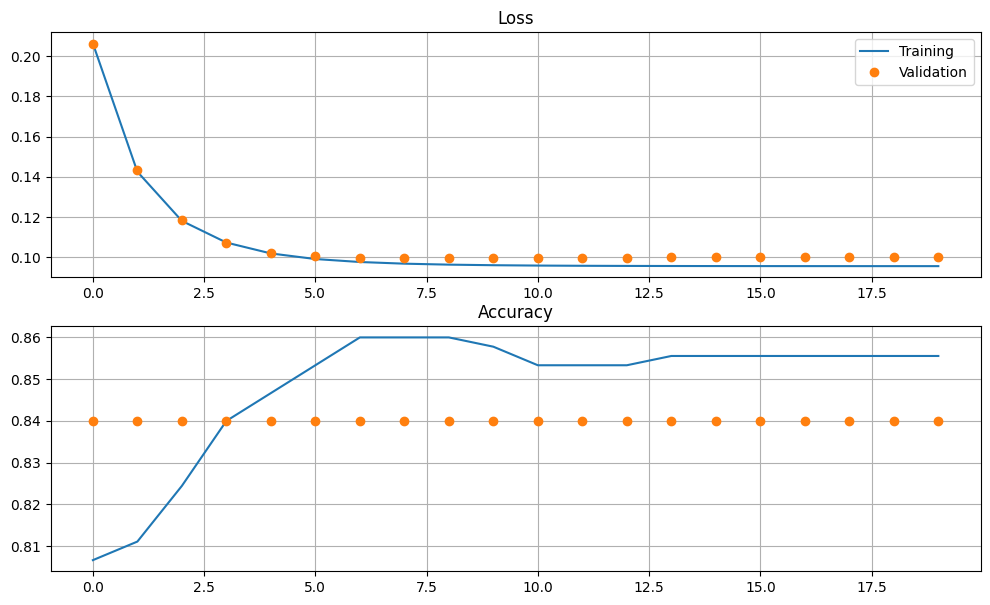

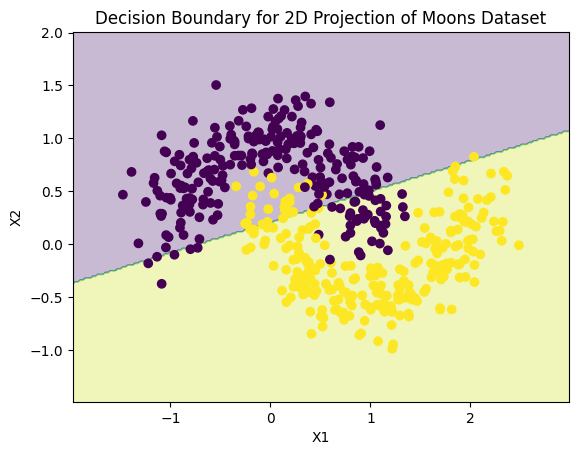

In [ ]:
model = NeuralNetwork(textbook=True)

train_hist = model.fit(X, y, learning_rate=0.1, epochs=20, validation_split=0.1, verbose=True)
loss_acc_graph(train_hist)
plot_decision_boundary(model)

# **Architectural and Functional Exploration**

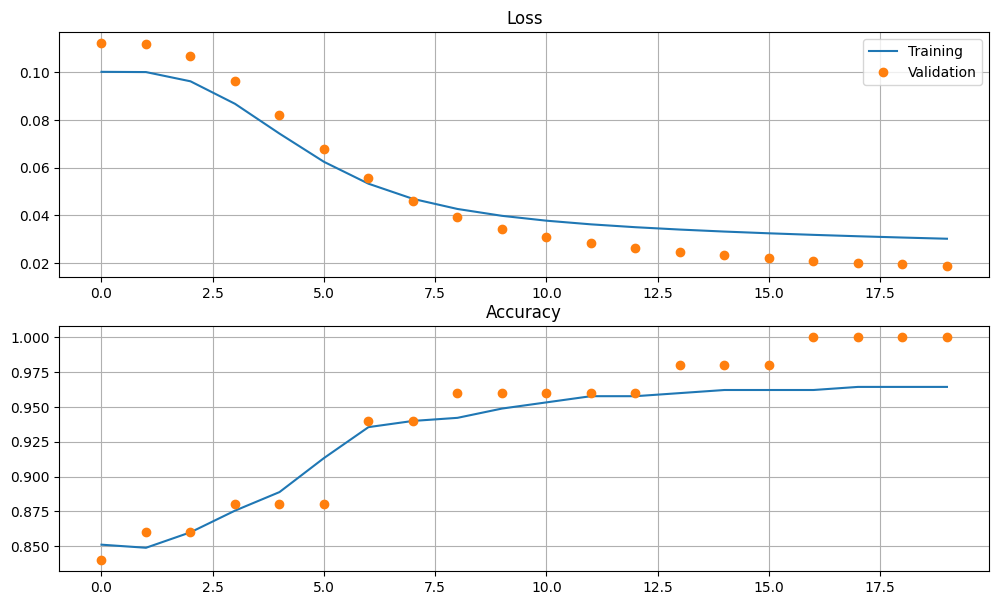

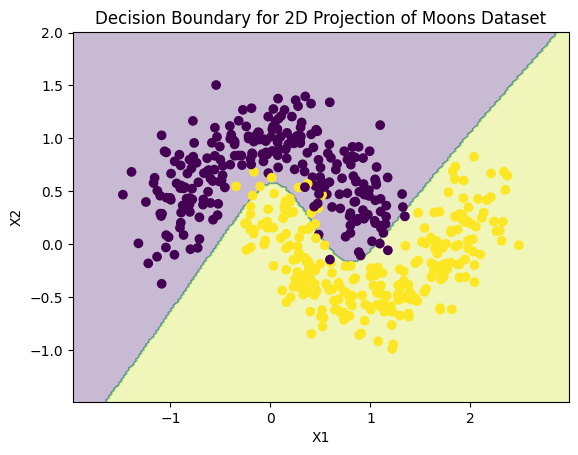

In [ ]:
#sigmoid
class SigmoidNN(NeuralNetwork):
    def _activation(self, x):
        return 1/(1 + np.exp(-x))

    def _activation_derivative(self, x):
        return self._activation(x)  * (1 - self._activation(x))
sigmoid_model = SigmoidNN(hidden_size=16,initialization_method='xavier')

sigmoid_train_hist = sigmoid_model.fit(X, y, learning_rate=0.5, epochs=20, validation_split=0.1)
loss_acc_graph(sigmoid_train_hist)
plot_decision_boundary(sigmoid_model)

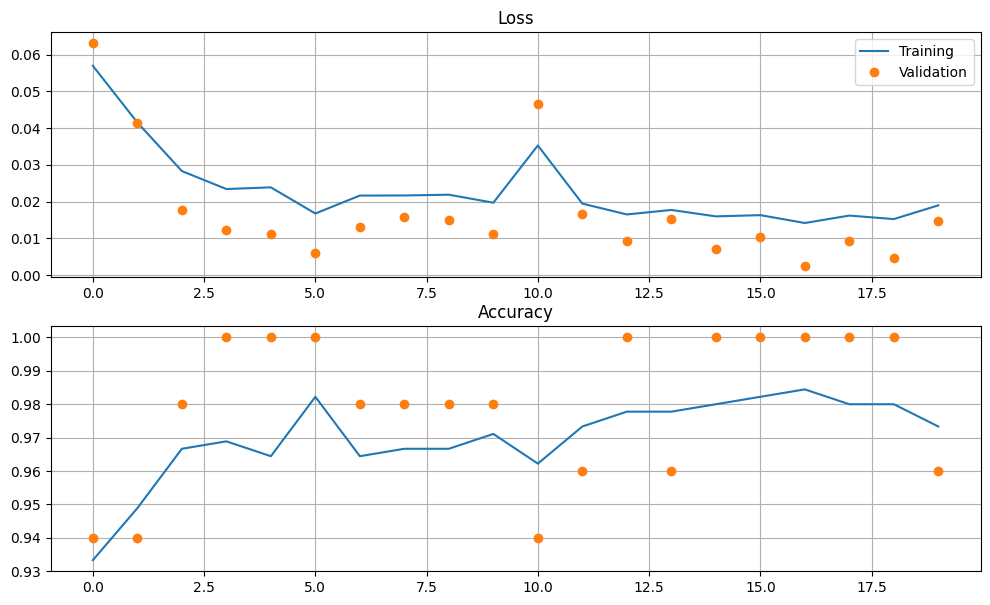

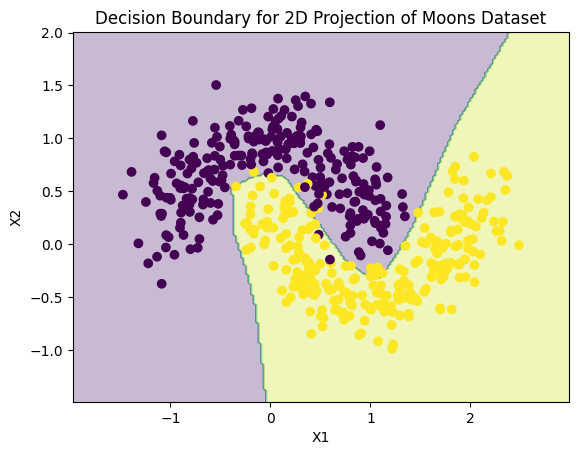

In [ ]:
##RELU
class ReluNN(NeuralNetwork):
    def _activation(self, x):
        return np.maximum(0, x)

    def _activation_derivative(self, x):
        return np.where(x>0, 1, 0)

relu_model = ReluNN(hidden_size=16,initialization_method='he')

relu_train_hist = relu_model.fit(X, y, learning_rate=0.5, epochs=20, validation_split=0.1)
loss_acc_graph(relu_train_hist)
plot_decision_boundary(relu_model)

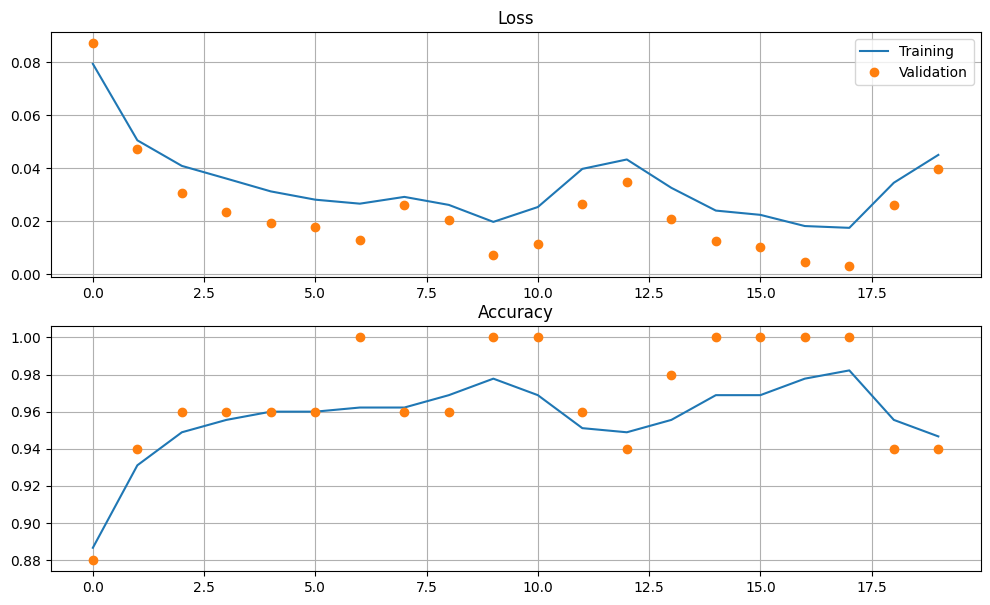

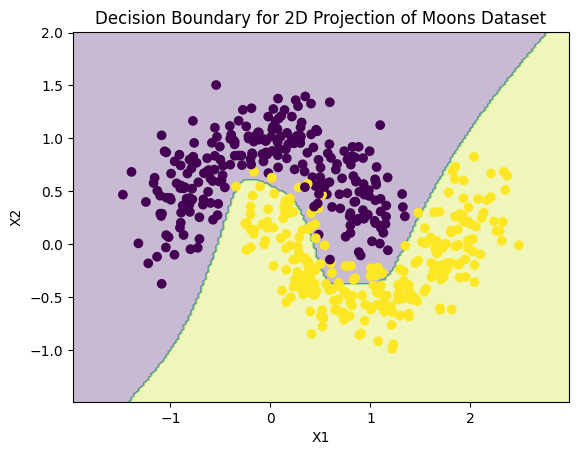

In [ ]:
##tanh
class TanhNN(NeuralNetwork):
    def _activation(self, x):
        return np.tanh(x)

    def _activation_derivative(self, x):
        return 1 - np.tanh(x)**2

tanh_model = TanhNN(hidden_size=16,initialization_method='xavier')

tanh_train_hist = tanh_model.fit(X, y, learning_rate=0.5, epochs=20, validation_split=0.1)
loss_acc_graph(tanh_train_hist)
plot_decision_boundary(tanh_model)

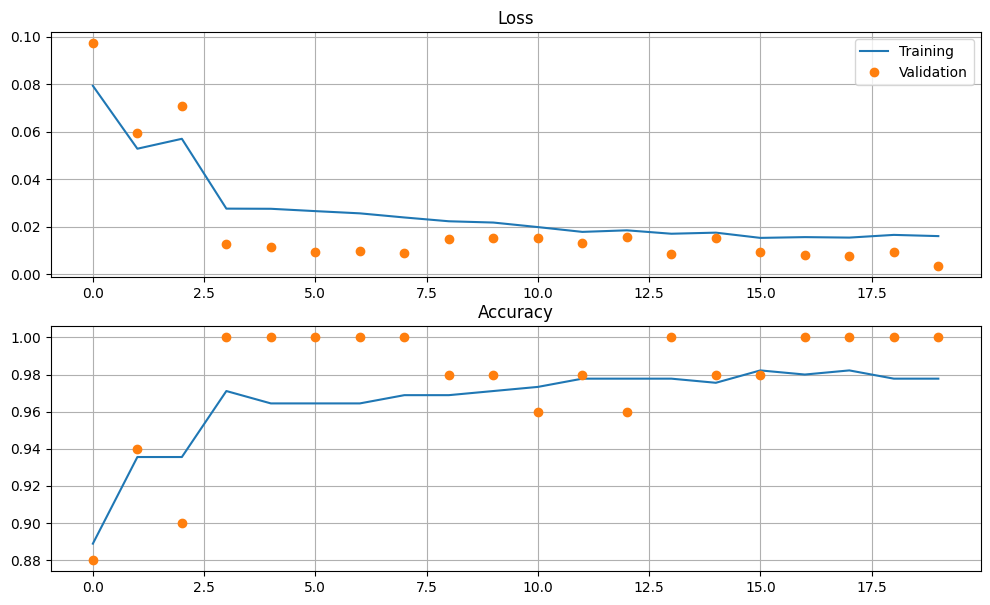

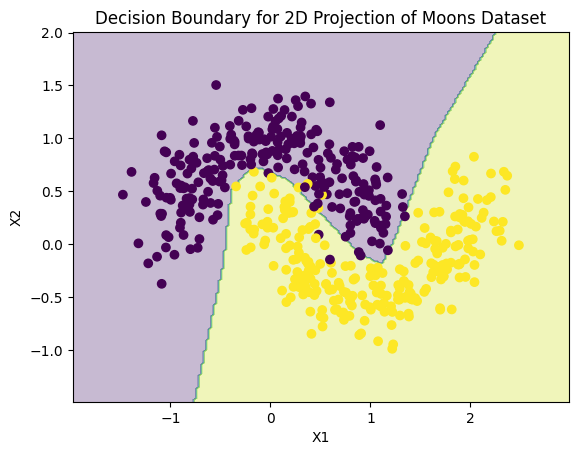

In [ ]:
##leaky ReLU
class LeakyReluNN(NeuralNetwork):
    def _activation(self, x):
        return np.maximum(0.01*x, x)

    def _activation_derivative(self, x):
        return np.where(x>0, 1, 0.01)

lr_model = LeakyReluNN(hidden_size=16,initialization_method='he')

lr_train_hist = lr_model.fit(X, y, learning_rate=0.5, epochs=20, validation_split=0.1)
loss_acc_graph(lr_train_hist)
plot_decision_boundary(lr_model)

#**Neural network from scratch**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.9060
Epoch 200, Loss: 1.2926
Epoch 300, Loss: 1.3655
Epoch 400, Loss: 1.3844
Epoch 500, Loss: 1.3916
Epoch 600, Loss: 1.3962
Epoch 700, Loss: 1.4001
Epoch 800, Loss: 1.4037
Epoch 900, Loss: 1.4070

Test Accuracy: 0.9000


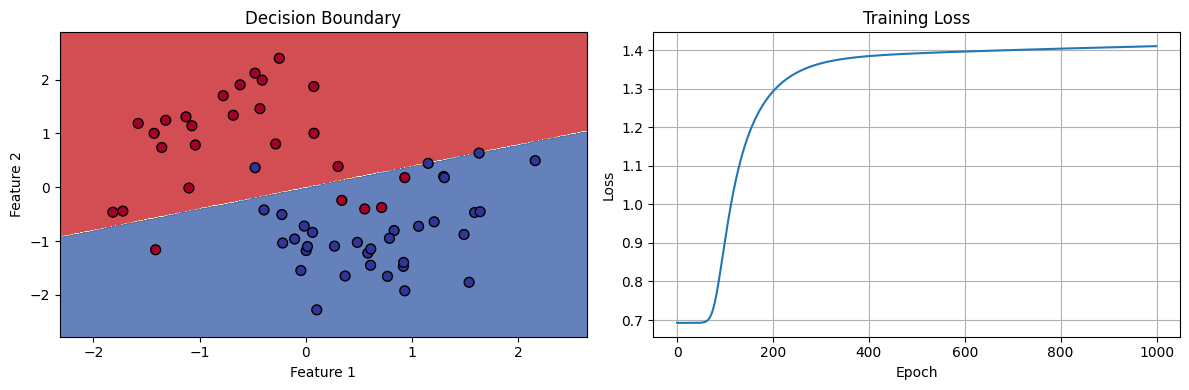

In [ ]:
class MLP:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        # Initialize weights and biases
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))
        self.learning_rate = learning_rate
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, X):
        # Hidden layer
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        # Output layer
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output):
        m = X.shape[0]

        # Output layer error
        d_z2 = output - y.reshape(-1, 1)
        d_W2 = (1/m) * np.dot(self.a1.T, d_z2)
        d_b2 = (1/m) * np.sum(d_z2, axis=0, keepdims=True)

        # Hidden layer error
        d_a1 = np.dot(d_z2, self.W2.T)
        d_z1 = d_a1 * self.sigmoid_derivative(self.a1)
        d_W1 = (1/m) * np.dot(X.T, d_z1)
        d_b1 = (1/m) * np.sum(d_z1, axis=0, keepdims=True)

        # Update weights and biases
        self.W2 -= self.learning_rate * d_W2
        self.b2 -= self.learning_rate * d_b2
        self.W1 -= self.learning_rate * d_W1
        self.b1 -= self.learning_rate * d_b1

    def train(self, X, y, epochs=1000, verbose=True):
        losses = []
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output)

            # Calculate loss (binary cross-entropy)
            loss = -np.mean(y * np.log(output + 1e-8) + (1-y) * np.log(1 - output + 1e-8))
            losses.append(loss)

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

        return losses

    def predict(self, X):
        return (self.forward(X) > 0.5).astype(int)

# Generate synthetic dataset
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# Split and scale data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train MLP
mlp = MLP(input_size=2, hidden_size=10, output_size=1, learning_rate=0.5)
losses = mlp.train(X_train_scaled, y_train, epochs=1000, verbose=True)

# Evaluate
y_pred = mlp.predict(X_test_scaled)
accuracy = np.mean(y_pred.flatten() == y_test)
print(f"\nTest Accuracy: {accuracy:.4f}")

# Plot decision boundary
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='black', s=50)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.subplot(1, 2, 2)
    plt.plot(losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_decision_boundary(mlp, X_test_scaled, y_test)